<a href="https://colab.research.google.com/github/DilshanBotheju/freshsense-imagemodel/blob/dilshan/FreshSenseEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import ncessary libraries
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
import glob

In [4]:
# Loading the dataset
BASE_PATH = "/content/drive/MyDrive/FreshSense/dataset"

datasets = ["banana_dataset", "cucumber_dataset", "tomato_dataset"]
classes = ["fresh", "atrisk", "spoiled"]

In [6]:
# Dataset Distribution
data = []

for ds in datasets:
    ds_path = os.path.join(BASE_PATH, ds)
    for cls in classes:
        img_path = os.path.join(ds_path, cls, "images")

        if os.path.exists(img_path):
            images = glob.glob(os.path.join(img_path, "*.*"))
            count = len(images)
            data.append({
                "Item": ds.replace("_dataset", "").title(),
                "Class": cls.title(),
                "Count": count
            })

In [7]:
# Create dataframe
df = pd.DataFrame(data)
print(df)

       Item    Class  Count
0    Banana    Fresh    357
1    Banana   Atrisk    387
2    Banana  Spoiled    400
3  Cucumber    Fresh    430
4  Cucumber   Atrisk    367
5  Cucumber  Spoiled    336
6    Tomato    Fresh    304
7    Tomato   Atrisk    313
8    Tomato  Spoiled    307


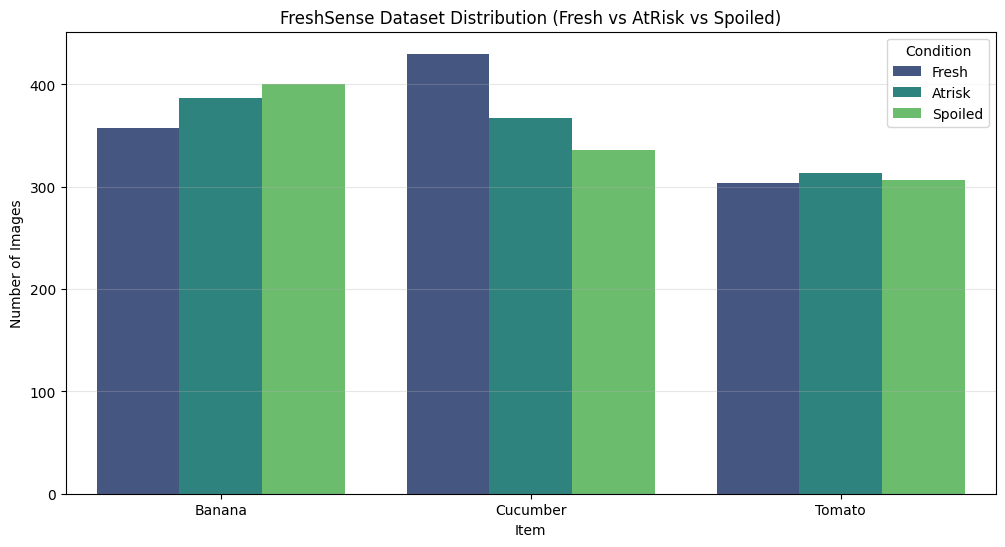

In [8]:
# Barchart class distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Item", y="Count", hue="Class", palette="viridis")
plt.title("FreshSense Dataset Distribution (Fresh vs AtRisk vs Spoiled)")
plt.ylabel("Number of Images")
plt.xlabel("Item")
plt.legend(title="Condition")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [9]:
# Total images per item
total_per_item = df.groupby("Item")["Count"].sum()
print("\nTotal images per item:")
print(total_per_item)


Total images per item:
Item
Banana      1144
Cucumber    1133
Tomato       924
Name: Count, dtype: int64


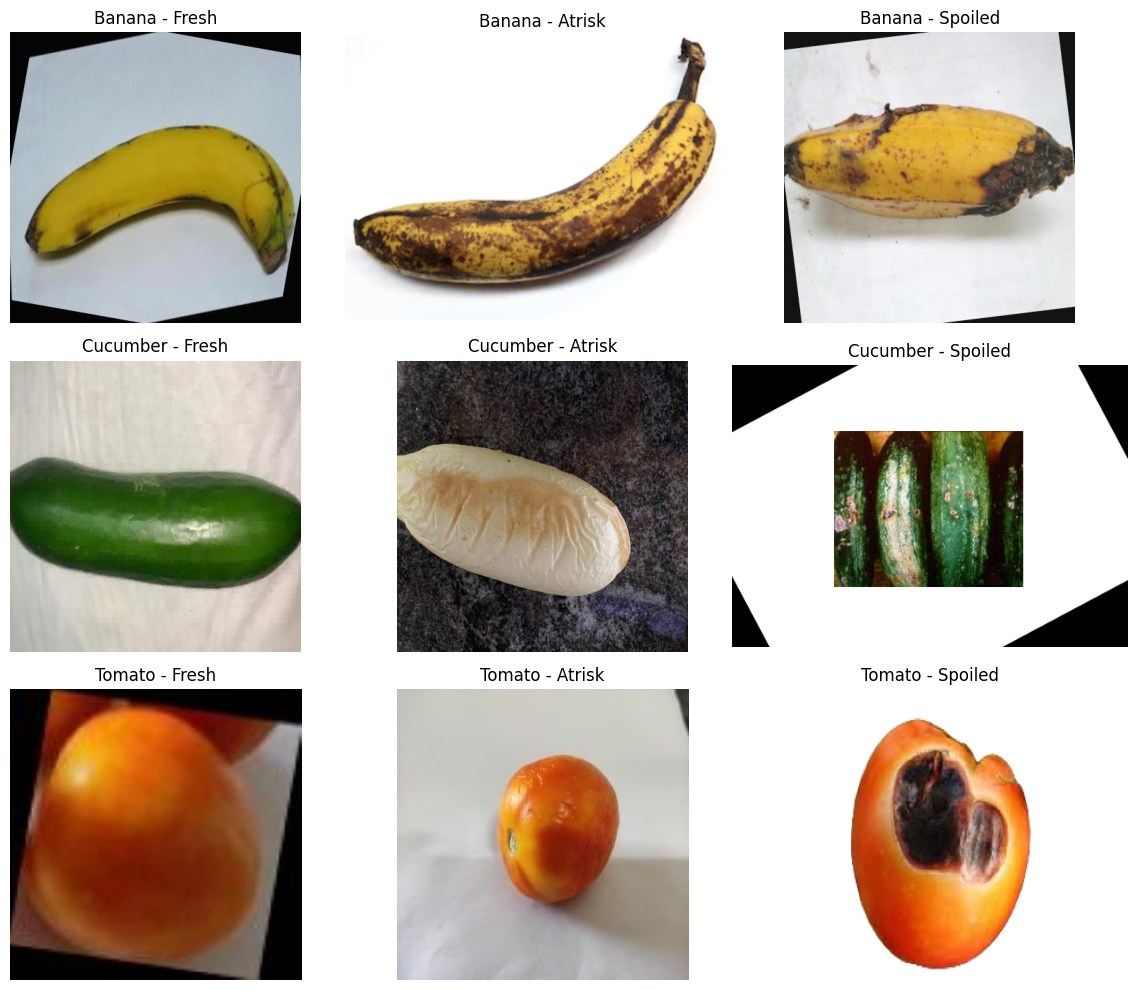

In [10]:
# Sample images from each category
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
idx = 0
for ds in datasets:
    for cls in classes:
        img_dir = os.path.join(BASE_PATH, ds, cls, "images")
        images = glob.glob(os.path.join(img_dir, "*.*"))
        if images:
            img = Image.open(images[0])
            axes[idx//3, idx%3].imshow(img)
            axes[idx//3, idx%3].set_title(f"{ds.replace('_dataset','').title()} - {cls.title()}")
            axes[idx//3, idx%3].axis("off")
            idx += 1
plt.tight_layout()
plt.show()

In [11]:
# Visualization of image size satistics for first 50 images
sizes = []
for ds in datasets:
    for cls in classes:
        img_dir = os.path.join(BASE_PATH, ds, cls, "images")
        for img_path in glob.glob(os.path.join(img_dir, "*.*"))[:50]:
            try:
                w, h = Image.open(img_path).size
                sizes.append({"Item": ds.replace("_dataset","").title(),
                              "Width": w, "Height": h})
            except:
                pass

size_df = pd.DataFrame(sizes)
print("\nImage Size Statistics:")
print(size_df.groupby("Item")[["Width", "Height"]].describe())


Image Size Statistics:
          Width                                                            \
          count        mean        std    min    25%    50%    75%    max   
Item                                                                        
Banana    150.0  422.360000  35.432568  416.0  416.0  416.0  416.0  696.0   
Cucumber  150.0  588.466667  67.234306  450.0  512.0  640.0  640.0  640.0   
Tomato    150.0  256.000000   0.000000  256.0  256.0  256.0  256.0  256.0   

         Height                                                        
          count    mean        std    min    25%    50%    75%    max  
Item                                                                   
Banana    150.0  416.48   9.431292  372.0  416.0  416.0  416.0  500.0  
Cucumber  150.0  582.40  83.478728  320.0  512.0  640.0  640.0  640.0  
Tomato    150.0  256.00   0.000000  256.0  256.0  256.0  256.0  256.0  
